## Read and Setup Dataset

In [1]:
import pandas as pd
fp = "../data/generated_biomass_MW_series.csv"
df = pd.read_csv(fp)

In [2]:
df.columns = ["time", "signal"]
df["time"] = pd.to_datetime(df["time"])
df

,time,signal
0,2018-04-12 06:00:00+00:00,381.0
1,2018-04-12 07:00:00+00:00,383.0
2,2018-04-12 08:00:00+00:00,385.0
3,2018-04-12 09:00:00+00:00,378.0
4,2018-04-12 10:00:00+00:00,379.0
...,...,...
2155,2018-07-11 01:00:00+00:00,313.0
2156,2018-07-11 02:00:00+00:00,314.0
2157,2018-07-11 03:00:00+00:00,320.0
2158,2018-07-11 04:00:00+00:00,325.0


## Setup Observation Logging 
We will be using Jinja templates to log observations about the data as we discover them. The observations are collected in a list and then logged to KMDS finally.

### Basic Descriptive Statistics

In [3]:
ts_obs = []

In [4]:
from scipy.stats import iqr
import numpy as np
data = df.signal.values
# Calculate the IQR
# Default percentiles are (25, 75)
iqr_value = iqr(data)
print(f"IQR: {iqr_value}")

# Calculate Q1 and Q3 manually using numpy for demonstration of bounds calculation
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
print(f"Q1: {Q1}, Q3: {Q3}")

# Calculate bounds
lower_bound = Q1 - 1.5 * iqr_value
upper_bound = Q3 + 1.5 * iqr_value
outlier = (data < lower_bound) | (data > upper_bound)
df["outlier"] = outlier

IQR: 72.0
Q1: 290.0, Q3: 362.0


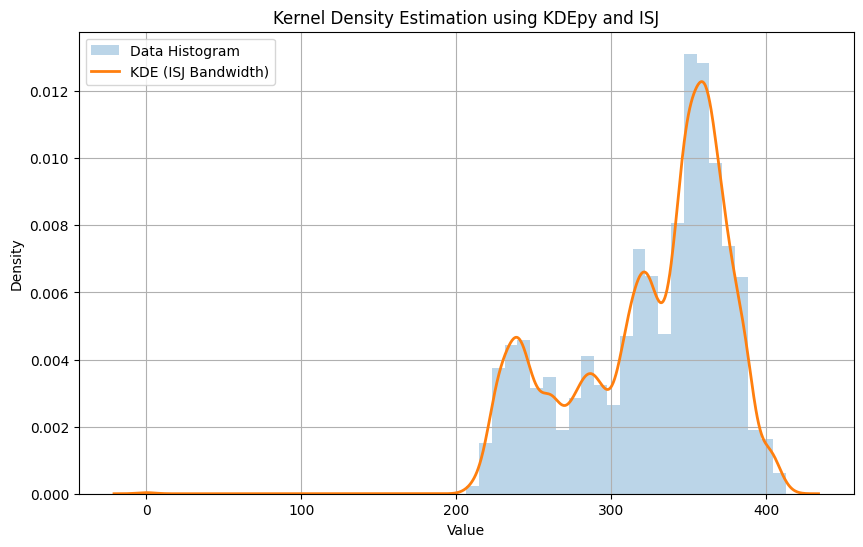

In [5]:

import matplotlib.pyplot as plt
from KDEpy import FFTKDE
from scipy.stats import norm

# 1. Generate or define a sample signal (multimodal data)
np.random.seed(42)
data = df.signal.values

# 2. Compute density estimates using 'ISJ' - Improved Sheather Jones
# FFTKDE is fast for large datasets
x, y = FFTKDE(kernel='gaussian', bw='ISJ').fit(data).evaluate(2**10)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.3, label='Data Histogram')
plt.plot(x, y, label='KDE (ISJ Bandwidth)', linewidth=2)
plt.title('Kernel Density Estimation using KDEpy and ISJ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from scipy.stats import iqr
import numpy as np
data = df.signal.values
# Calculate the IQR
# Default percentiles are (25, 75)
iqr_value = iqr(data)
print(f"IQR: {iqr_value}")

# Calculate Q1 and Q3 manually using numpy for demonstration of bounds calculation
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
print(f"Q1: {Q1}, Q3: {Q3}")

# Calculate bounds
lower_bound = Q1 - 1.5 * iqr_value
upper_bound = Q3 + 1.5 * iqr_value
outlier = (data < lower_bound) | (data > upper_bound)
df["outlier"] = outlier

IQR: 72.0
Q1: 290.0, Q3: 362.0


In [7]:
outlier_prop = df[df.outlier == True].shape[0]/df.shape[0]

In [8]:
outlier_prop

0.000462962962962963

In [9]:
from observation_log import ObservationTemplates
ObservationTemplates.DESCRIPTIVE_STATISTICS

'Descriptive Statistics: There were {{num_samples}} samples, taken at a frequency of {{sampling_rate}}. The mean was {{ "%0.2f" | format(mean)}} and the standard deviation was {{ "%0.2f" | format(std)}}. Evaluation of the histogram and kernel density plots reveals a {{modality}} distribution.'

In [10]:
data = {"num_samples": df.shape[0],
"sampling_rate": "hourly",
"mean" : np.mean(df.signal),
"std": np.std(df.signal),
 "modality": "multimodal"
}

from jinja2 import Template
j2_template = Template(ObservationTemplates.DESCRIPTIVE_STATISTICS)
rendered_output = j2_template.render(data)

In [11]:
from observation_log import ObsCat
obs = (ObsCat.DESCRIPTIVE_STATISTICS, rendered_output)
ts_obs.append(obs)

In [12]:
min_sig = df.signal.min()
df.loc[580, "signal"] = (df.loc[579, "signal"] + df.loc[581, "signal"])/2


In [13]:
df.loc[580, :]

time       2018-05-06 10:00:00+00:00
signal                         353.0
outlier                         True
Name: 580, dtype: object

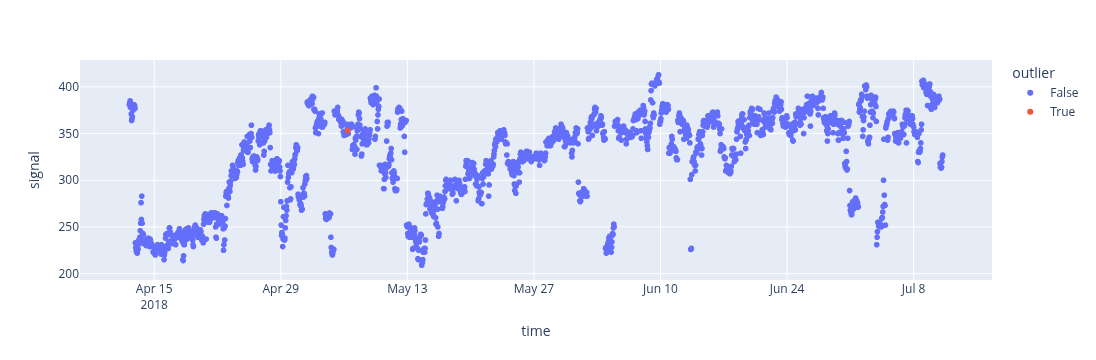

In [14]:
import plotly.express as px


# Create the line plot with markers
fig = px.scatter(df, x="time", y="signal", color="outlier")

# Display the figure
fig.show()

In [15]:
ObservationTemplates.OUTLIERS

'Outliers: Using the interquartile range (IQR) metric, the proportion of outliers was found to be {{ "%0.2f" | format(outlier_proportion)}}.'

In [16]:
data = {"outlier_proportion": outlier_prop
}

j2_template = Template(ObservationTemplates.OUTLIERS)
rendered_output = j2_template.render(data)

obs = (ObsCat.OUTLIERS, rendered_output)
ts_obs.append(obs)

In [17]:
data = {"remarks": """There was a single value of zero, looks like a data error. This was fixed with linear interpolation."""
}

j2_template = Template(ObservationTemplates.RAW_PLOTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.RAW_PLOTS, rendered_output)
ts_obs.append(obs)

## Prepare for SSA
1. Define Window
2. Run SSA
3. Analyze Eigen Value Plot

In [18]:
series = df.signal
series.index = df.time

In [19]:
series.iloc[580]

np.float64(353.0)

In [20]:
from ssalib import SingularSpectrumAnalysis
wdw = 24
ssa = SingularSpectrumAnalysis(series, window=wdw)
ssa.decompose()

SingularSpectrumAnalysis(timeseries=<Series shape=(2160,)>, window=24, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

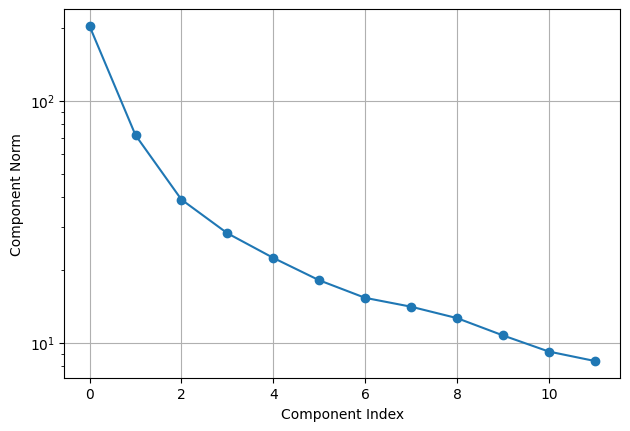

In [21]:
fig, ax = ssa.plot(n_components=12, marker='o')
plt.grid(True)

In [22]:

import numpy as np

# Suppose 's' contains the singular values from SVD
# s = [sigma1, sigma2, ..., sigmaL]
eigenvalues = ssa.eigenvalues
total_variance = np.sum(eigenvalues)
exp_var = {"var_comp-" + str(i+1) : (eigenvalues[i]/total_variance).item() for i in range(eigenvalues.shape[0])}
cum_var = {"var_comp-" + str(i+1) : (np.sum(eigenvalues[:i+1])/total_variance).item() for i in range(eigenvalues.shape[0])}

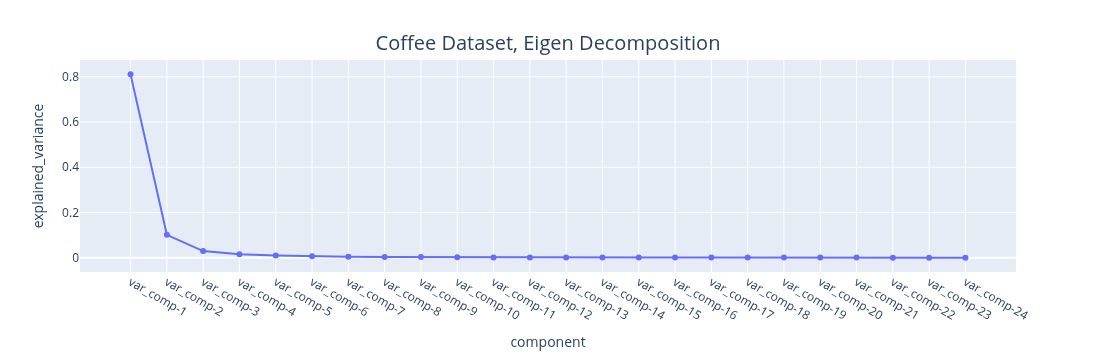

In [23]:
import plotly.express as px
df_eig = pd.DataFrame.from_dict(exp_var, orient="index").reset_index()
df_eig.columns = ["component", "explained_variance"]
# Create the line plot with markers
fig = px.line(df_eig, x="component", y="explained_variance", markers=True)
fig.update_layout(
    title={
        'text': "Coffee Dataset, Eigen Decomposition",
        'y':0.9, # Position (0-1)
        'x':0.5, # Position (0-1)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=20)
    }
)
# Display the figure
fig.show()

In [24]:
df_cv = pd.DataFrame.from_dict(cum_var, orient="index").reset_index()
df_cv.columns = ["component", "explained_variance"]

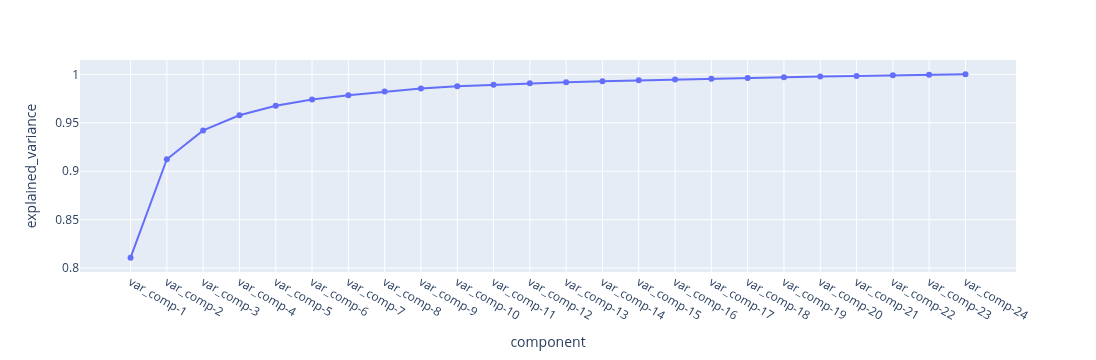

In [25]:



# Create the line plot with markers
fig = px.line(df_cv, x="component", y="explained_variance", markers=True)

# Display the figure
fig.show()

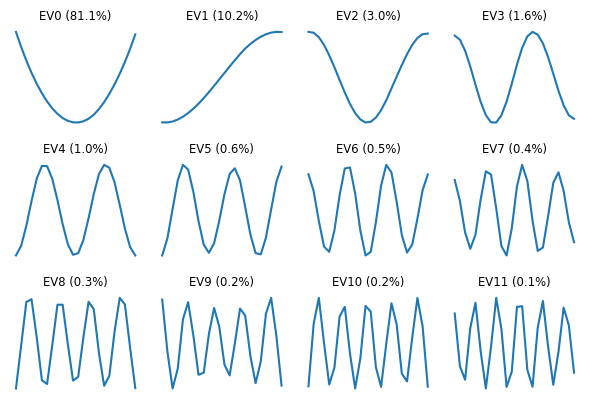

In [26]:
fig, axes = ssa.plot(kind='vectors')

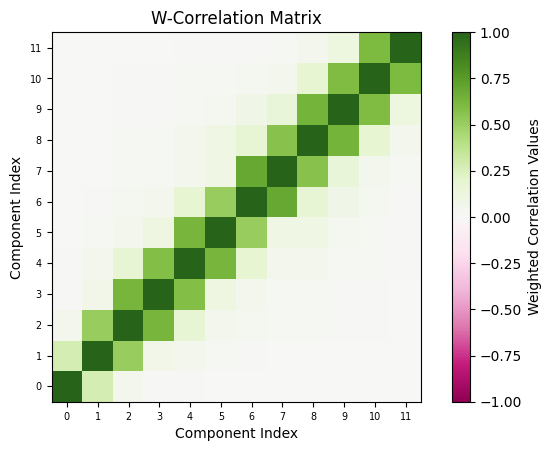

In [27]:
fig, ax = ssa.plot(kind='wcorr', n_components=12)
_ = ax.set_xlabel('Component Index')
_ = ax.set_ylabel('Component Index')
cbar = ax.collections[0].colorbar
cbar.set_label('Weighted Correlation Values')

In [28]:
ObservationTemplates.GROUPING

'Grouping: Based on the correlation plot, the following components can be grouped together: {{ comma_sep_components }}.'

In [29]:
data = {"comma_sep_components": "(0,1,2,3,4)"
}

j2_template = Template(ObservationTemplates.GROUPING)
rendered_output = j2_template.render(data)
obs = (ObsCat.GROUPING, rendered_output)
ts_obs.append(obs)

## Apply Grouping

In [30]:
res = [j for j in range(5,24)]

In [31]:
res

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

In [32]:
ssa.reconstruct(groups={'Trend': [0,1,2,3,4] ,'Seasonal': [], "residuals":res})

SingularSpectrumAnalysis(timeseries=<Series shape=(2160,)>, window=24, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

In [33]:
trend_data = {"time": df.time.values, "trend": ssa["Trend"].values, "raw":ssa["ssa_preprocessed"].values}
df_trend = pd.DataFrame.from_dict(trend_data, orient="columns")

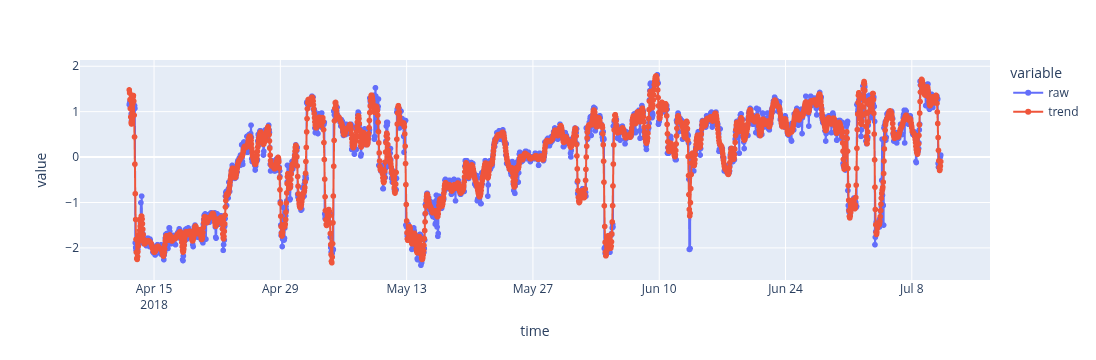

In [34]:
# Create the line plot with markers
fig = px.line(df_trend, x="time", y=["raw","trend"], markers=True)

# Display the figure
fig.show()

In [35]:
ObservationTemplates.SMOOTHED_PLOTS

'Smoothed Plots: Visually, the Singular Spectrum Analysis (SSA) appears to achieve {{reconstruction_quality}} reconstruction. {{notes_for_cycles_trends_seasonality}}'

In [36]:
data = {"reconstruction_quality": "a very good",
        "notes_for_cycles_trends_seasonality": """Trends exist for some part of the observation period, trend-cycles are present, no apparent seasonality evident."""
}

j2_template = Template(ObservationTemplates.SMOOTHED_PLOTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.SMOOTHED_PLOTS, rendered_output)
ts_obs.append(obs)

In [37]:
obs = (ObsCat.CHANGE_POINTS, ObservationTemplates.CHANGE_POINTS)
ts_obs.append(obs)


## Residual Analysis

ssa["residuals"]

In [38]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [39]:

# 3. Perform the Durbin-Watson test
dw_statistic = durbin_watson(ssa["residuals"].values)

print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 1.6095007074771885


<Axes: ylabel='Density'>

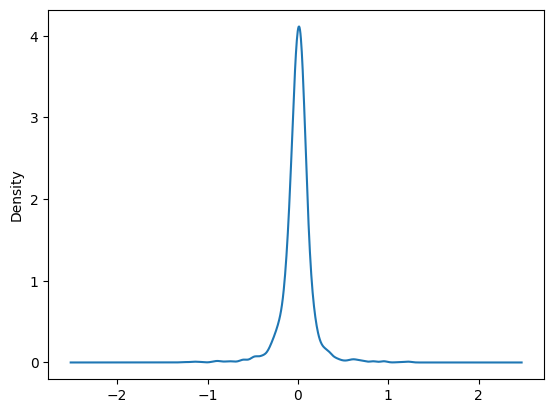

In [40]:
ssa["residuals"].plot.kde()

1. The residuals do not explain a lot of variation in the signal
2. Change point detection on the residuals, run with the assumption that we don't know the the change points apriori, with a
penalty $\beta = 2 . \log(N)$ suggests there are no change points in the noise. The implication is that unexplained variance does not change over the observation period. The change points of interest are in the trend and seasonal component.

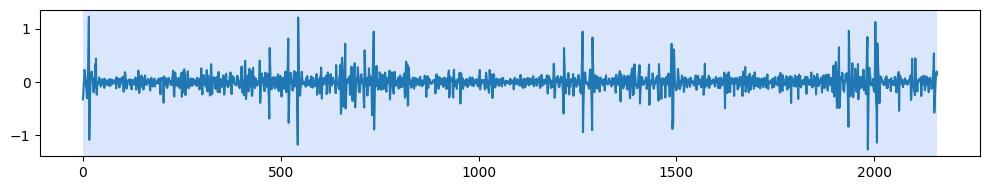

In [41]:
import ruptures as rpt
import matplotlib.pyplot as plt
from math import log
algo = rpt.Pelt(model="rbf").fit(ssa["residuals"].values)
rec_pen = 2*log(ssa["residuals"].shape[0],2)
# 3. Predict the change points
# The 'pen' parameter controls the sensitivity (higher penalty, fewer change points)
result = algo.predict(pen=rec_pen)

# 4. Display the results (optional, requires matplotlib)
rpt.display(ssa["residuals"].values, result)
plt.show()

In [42]:
import numpy as np
noise_signal = ssa["residuals"].values
median_value_noise = np.median(noise_signal)
binarized_signal = noise_signal > median_value_noise

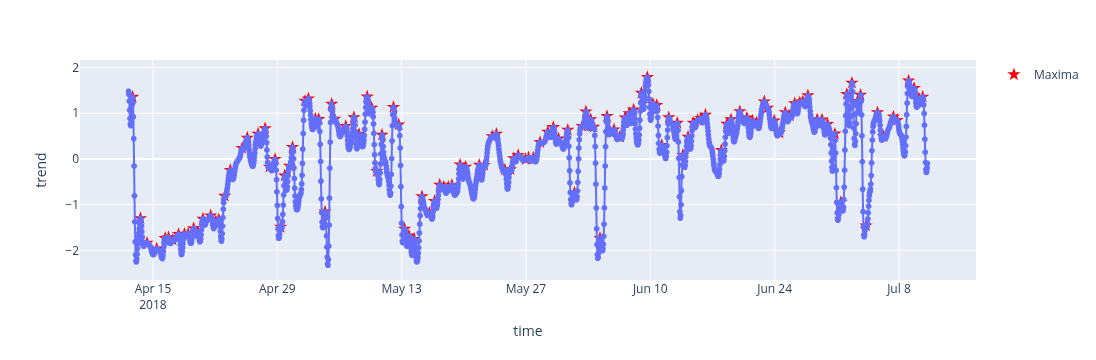

In [43]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
the_signal = df_trend.trend.values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
fig = px.line(df_trend, x="time", y="trend", markers=True)

#plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
fig.add_trace(
    go.Scatter(
        x= x[peaks_indices], y= the_signal[peaks_indices],
        mode='markers', # Set mode to markers
        name='Maxima', # Name for the legend
        marker=dict(color='red', size=10, symbol='star'), # Customize the marker style
        showlegend=True
    )
)


# Display the figure
fig.show()

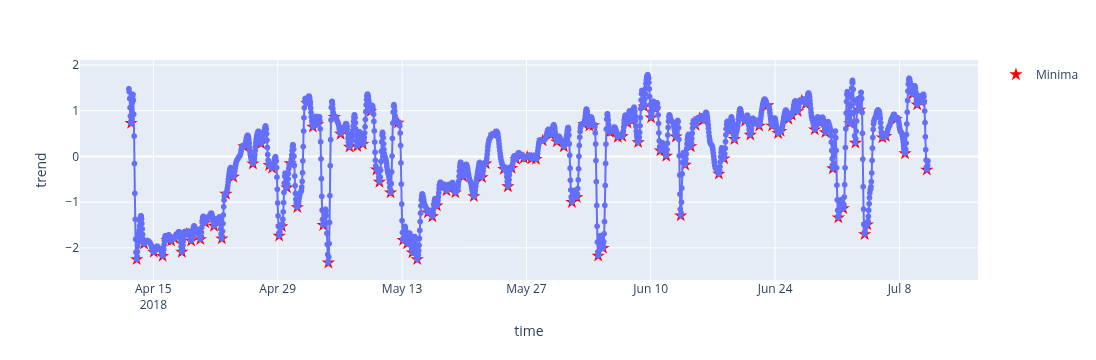

In [44]:

the_signal = -df_trend.trend.values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
the_signal = df_trend.trend.values

# 3. Plot the results (optional, but helpful for visualization)
fig = px.line(df_trend, x="time", y="trend", markers=True)

#plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
fig.add_trace(
    go.Scatter(
        x= x[peaks_indices], y= the_signal[peaks_indices],
        mode='markers', # Set mode to markers
        name='Minima', # Name for the legend
        marker=dict(color='red', size=10, symbol='star'), # Customize the marker style
        showlegend=True
    )
)


In [45]:

df_trend.rename(columns={"trend": "ssa"}, inplace=True)

In [46]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

# Apply lowess
smoothed_05 = lowess(df_trend.raw, df_trend.time, frac=0.05) # frac is fraction of data used
smoothed_10 = lowess(df_trend.raw, df_trend.time, frac=0.1) # frac is fraction of data used
from scipy.signal import savgol_filter
# Apply filter: window size 51, polynomial order 3
smoothed_savgol_51 = savgol_filter(df_trend.raw, 51, 3)
smoothed_savgol_21 = savgol_filter(df_trend.raw, 21, 3)

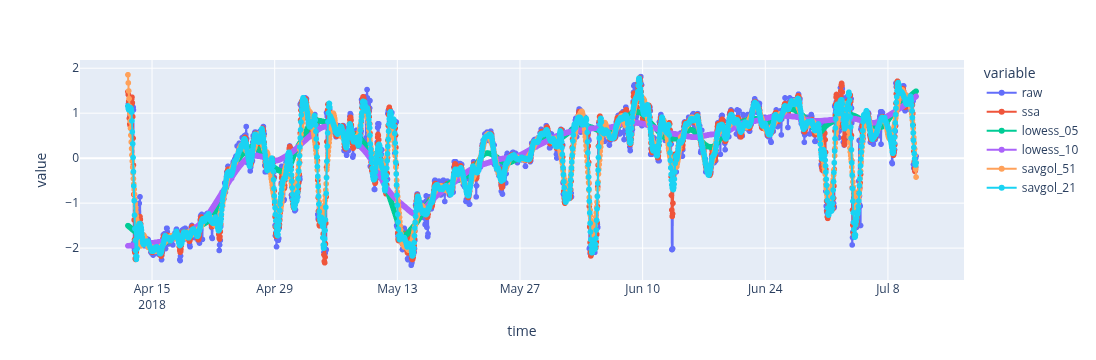

In [47]:
df_trend["lowess_05"] = smoothed_05[:,1]
df_trend["lowess_10"] = smoothed_10[:,1]
df_trend["savgol_51"] = smoothed_savgol_51
df_trend["savgol_21"] = smoothed_savgol_21
fig = px.line(df_trend, x="time", y=["raw","ssa", "lowess_05", "lowess_10", "savgol_51", "savgol_21"], markers=True)

# Display the figure
fig.show()

In [48]:
data = {"explained_variance": df_cv.loc[5, "explained_variance"].item() *100
}

j2_template = Template(ObservationTemplates.EXPLAINED_VARIANCE)
rendered_output = j2_template.render(data)
obs = (ObsCat.EXPLAINED_VARIANCE, rendered_output)
ts_obs.append(obs)

In [49]:
data = {"noise_estimate": (1 - df_cv.loc[5, "explained_variance"].item())*100
}

j2_template = Template(ObservationTemplates.ESTIMATED_NOISE)
rendered_output = j2_template.render(data)
obs = (ObsCat.ESTIMATED_NOISE, rendered_output)
ts_obs.append(obs)

/home/rajiv/programming/ts_exploration/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/rajiv/programming/ts_exploration/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


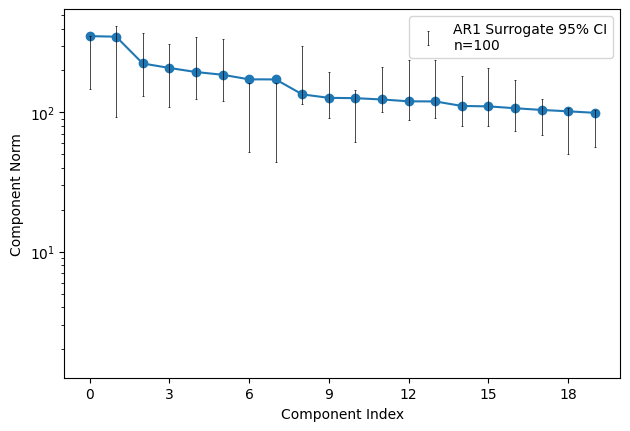

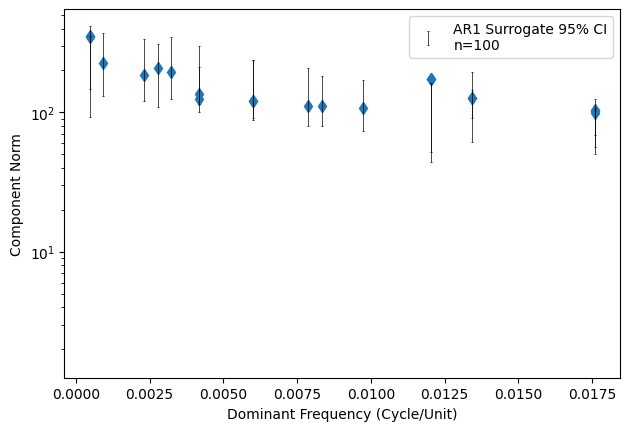

In [50]:

from ssalib import MonteCarloSSA
# Monte Carlo SSA
mcssa = MonteCarloSSA(
    df.signal,
    svd_solver='sklearn_randomized',
    ar_order_max=1,  # default
    criterion='bic',  # default
    n_surrogates=100,  # default
    random_seed=0
)
mcssa.decompose(n_components=20)
fig, ax = mcssa.plot(n_components=20, confidence_level=.95, marker='o')
fig, ax = mcssa.plot(
    n_components=20,
    rank_by='freq',
    confidence_level=.95,
    marker='d',
    ls='None'
)


In [51]:
ac = "With this dataset, it is reasonable to use the first 5 components to approximate the signal and the remainder to be noise."
ac += " The first component seems uncorrelated with the others."
ac += " Since the Durbin-Watson statistic is in the 1.5 to 2.5 range (1.7), we can treat the noise as independent"
ac += " Further, PELT reported no change points in the noise, so we can treat the noise as Independent Identically Distributed"
ac += " If your downstream task, needs to approximate the data as the sum of a smooth signal with IID noise, with this data, it is a reasonable choice."
ac += " For this dataset, Monte-Carlo simulation may be a reasonable assumption. We can think of other realizations of this dataset to be."
ac += " similar to this dataset, for the entire period. The signal components lie within the confidence intervals obtained from the simulation."
data = {"correlated": "uncorrelated",
        "additional_comments": ac
       }

j2_template = Template(ObservationTemplates.SPECIFIC_COMMENTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.SPECIFIC_COMMENTS, rendered_output)
ts_obs.append(obs)

In [52]:

file_path = "../data/biomass_ts_observations.txt"
with open(file_path, 'w') as file:
    for cat, obs in ts_obs:
        # Convert the named tuple to a string and add a newline character
        file.write(f"Category: {cat.value}\n")
        file.write(f"Observation: {obs}\n")

## Knowledge Base Logging

In [53]:
from kmds.ontology.kmds_ontology import *
from kmds.tagging.tag_types import ExploratoryTags
kaw = KnowledgeExtractionExperimentationWorkflow("biomass_per_hour_generation_4_year_data_SPAIN", namespace=onto)

In [54]:
from kmds.ontology.intent_types import IntentType
exp_obs_list = []
observation_count :int = 1
e1 = ExploratoryObservation(namespace=onto)

In [55]:
from kmds.ontology.intent_types import IntentType
exp_obs_list = []
observation_count :int = 1
e1 = ExploratoryObservation(namespace=onto)

In [56]:
for cat, obs in ts_obs:
    observation_count += 1
    e = ExploratoryObservation(namespace=onto)
    e.finding = obs
    e.finding_sequence = observation_count
    e.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
    e.intent = IntentType.DATA_UNDERSTANDING.value
    exp_obs_list.append(e)

kaw.has_exploratory_observations = exp_obs_list 

In [57]:
from owlready2 import *
from kmds.utils.path_utils import get_package_kb_path
KNOWLEDGE_BASE = "../data/kmds/coffee_prices_analysis.xml"
onto.save(file=KNOWLEDGE_BASE, format="rdfxml")